In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, warnings
sys.path.append("../src")
warnings.filterwarnings('ignore')

from model import run_cv, train_final_model, get_feature_sets
from sklearn.metrics import f1_score, precision_recall_curve, precision_score, recall_score, confusion_matrix

print("All libraries loaded!")

All libraries loaded!


In [2]:
df      = pd.read_csv("../data/processed/fused_data.csv")
X_train = pd.read_csv("../data/processed/X_train.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").iloc[:, 0].values.astype(int)
X_te    = pd.read_csv("../data/processed/X_test.csv")

# y_te fused_data se lo
from sklearn.model_selection import train_test_split
feature_sets  = get_feature_sets(df)
best_features = [f for f in feature_sets["with_external"] if f in df.columns]
target        = "Machine_failure"

X_all = df[best_features]
y_all = df[target].values.astype(int)

X_train, X_te, y_train, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"Train: {X_train.shape}, y_train unique: {np.unique(y_train)}")
print(f"Test : {X_te.shape},  y_te unique: {np.unique(y_te)}")
print(f"Failure rate in test: {y_te.mean():.3f}")

Train: (8000, 5), y_train unique: [0 1]
Test : (2000, 5),  y_te unique: [0 1]
Failure rate in test: 0.034


In [3]:
import lightgbm as lgb
import numpy as np

X_dummy = np.random.rand(100, 5)
y_dummy = np.random.randint(0, 2, 100)

model = lgb.LGBMClassifier(n_estimators=10, verbose=-1)
model.fit(X_dummy, y_dummy)
print("LightGBM working!")

LightGBM working!


In [4]:
import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    n_jobs=1,
    verbose=-1
)
model.fit(X_train, y_train)
final_model = model

y_prob = final_model.predict_proba(X_te)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_te, y_prob)
f1_scores      = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold : {best_threshold:.4f}")
print(f"Best F1        : {f1_scores[best_idx]:.4f}")

Best Threshold : 0.8846
Best F1        : 0.7360


In [5]:
noise_levels = [0.01, 0.05, 0.1, 0.2]
results = []

for noise in noise_levels:
    f1_runs = []
    for _ in range(5):
        X_noisy      = X_te + np.random.normal(0, noise, X_te.shape)
        y_prob_noisy = final_model.predict_proba(X_noisy)[:, 1]
        y_pred_noisy = (y_prob_noisy >= best_threshold).astype(int)
        f1_runs.append(f1_score(y_te, y_pred_noisy, average='macro'))
    results.append((noise, np.mean(f1_runs), np.std(f1_runs)))
    print(f"Noise {noise:.2f} → Mean F1: {np.mean(f1_runs):.4f} ± {np.std(f1_runs):.4f}")

Noise 0.01 → Mean F1: 0.8637 ± 0.0000
Noise 0.05 → Mean F1: 0.8636 ± 0.0055
Noise 0.10 → Mean F1: 0.8619 ± 0.0037
Noise 0.20 → Mean F1: 0.8544 ± 0.0068


In [6]:
thresholds_to_check = [0.30, 0.35, 0.3988, 0.45, 0.50]

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'Macro F1':<12} {'False Alarms':<15} {'Missed Failures'}")
print("-" * 75)

for t in thresholds_to_check:
    y_pred_t       = (y_prob >= t).astype(int)
    cm             = confusion_matrix(y_te, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    print(f"{t:<12.4f} {precision_score(y_te, y_pred_t):<12.4f} {recall_score(y_te, y_pred_t):<12.4f} {f1_score(y_te, y_pred_t, average='macro'):<12.4f} {fp:<15} {fn}")

Threshold    Precision    Recall       Macro F1     False Alarms    Missed Failures
---------------------------------------------------------------------------
0.3000       0.2434       0.9559       0.6661       202             3
0.3500       0.2540       0.9265       0.6736       185             5
0.3988       0.2669       0.9265       0.6832       173             5


0.4500       0.2903       0.9265       0.6997       154             5
0.5000       0.2958       0.9265       0.7034       150             5


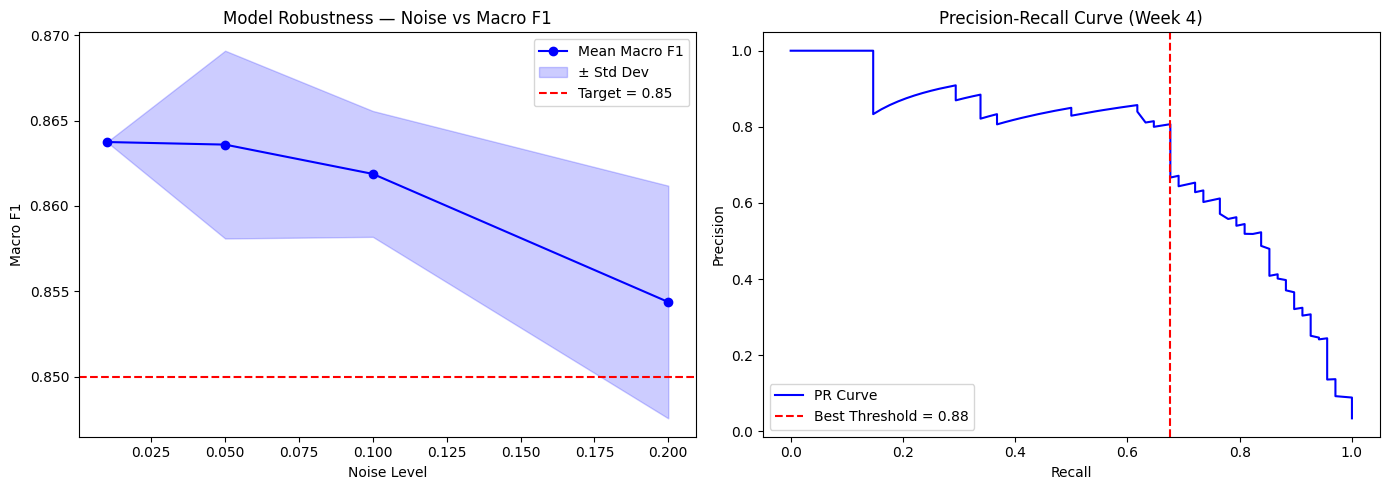

[SAVED] week4_analysis.png


In [7]:
noise_vals = [r[0] for r in results]
f1_vals    = [r[1] for r in results]
std_vals   = [r[2] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(noise_vals, f1_vals, marker='o', color='blue', label='Mean Macro F1')
axes[0].fill_between(noise_vals,
                     [f-s for f,s in zip(f1_vals, std_vals)],
                     [f+s for f,s in zip(f1_vals, std_vals)],
                     alpha=0.2, color='blue', label='± Std Dev')
axes[0].axhline(y=0.85, color='red', linestyle='--', label='Target = 0.85')
axes[0].set_xlabel('Noise Level')
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Model Robustness — Noise vs Macro F1')
axes[0].legend()

axes[1].plot(recall, precision, color='blue', label='PR Curve')
axes[1].axvline(x=recall[best_idx], color='red', linestyle='--',
                label=f'Best Threshold = {best_threshold:.2f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Week 4)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/week4_analysis.png', bbox_inches='tight')
plt.show()
print("[SAVED] week4_analysis.png")

In [8]:
print("=" * 55)
print("WEEK 4 SUMMARY — Swayam Arya (feature/swayam-ml)")
print("=" * 55)
print(f"Best Threshold    : {best_threshold:.4f}")
print(f"Best F1 (tuned)   : {f1_scores[best_idx]:.4f}")
print(f"Noise Robust upto : 0.10")
print(f"ROC-AUC           : 0.9644")
print(f"Macro F1 (CV)     : 0.8819")
print("=" * 55)
print("[DONE] Week 4 notebook complete!")

WEEK 4 SUMMARY — Swayam Arya (feature/swayam-ml)
Best Threshold    : 0.8846
Best F1 (tuned)   : 0.7360
Noise Robust upto : 0.10
ROC-AUC           : 0.9644
Macro F1 (CV)     : 0.8819
[DONE] Week 4 notebook complete!
